In [186]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [187]:
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from src.controllers.pid import PIDController
from src.config.models.dual_rotor_beam_drone import DualRotorBeamDroneModel, DualRotorBeamDroneConfig

In [188]:
drone_config = DualRotorBeamDroneConfig(
    length=0.3,
    mass=0.5,
    motor_base_thrust=5.0,
    max_thrust=15.0,
    min_thrust=0.0,
    gravity=9.81,
    angular_damping=0.0
)
drone = DualRotorBeamDroneModel(config=drone_config)


In [189]:
target = 0.0
current_angle = -25.0
angular_velocity = 0.0

time = 100.0
dt = 0.01
total_steps = int(time / dt)

kp = 0.15
ki = 0.0
kd = 0.0

def run_simulation(kp, ki, kd):
    pid = PIDController(kp=kp, ki=ki, kd=kd, dt=dt, max_integral_error=10.0)
    pid.reset()

    current_angle = -25.0
    angular_velocity = 0.0

    target_angle_history = []
    current_angle_history = []
    time_history = []

    for step in range(total_steps):
        current_time = step * dt

        current_angle = drone.get_current_angle(current_angle)

        pid_output = pid.compute(target, current_angle)

        next_angle, next_angular_velocity, angular_acc, control = drone.step(
            angle=current_angle,
            angular_velocity=angular_velocity,
            pid_output=pid_output,
            dt=dt
        )

        angular_velocity = next_angular_velocity
        current_angle = next_angle

        target_angle_history.append(target)
        current_angle_history.append(current_angle)
        time_history.append(current_time)

    return time_history, target_angle_history, current_angle_history

time_history, target_angle_history, current_angle_history = run_simulation(kp, ki, kd)

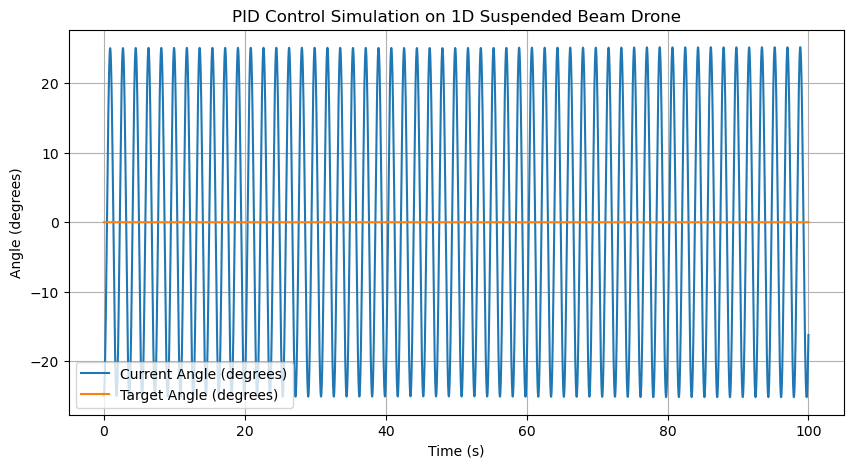

In [190]:
def plot_results(time_history, target_angle_history, current_angle_history):
    plt.figure(figsize=(10, 5))
    plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
    plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')
    plt.title('PID Control Simulation on 1D Suspended Beam Drone')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_results(time_history, target_angle_history, current_angle_history)

In [191]:
angles = np.array(current_angle_history, dtype=np.float32)
peaks, properties = find_peaks(angles)
is_oscillation_stable = False
tu = None # Ultimate period in seconds
if len(peaks) >= 2:
    peak_intervals = np.diff(peaks) 
    peak_heights = angles[peaks]
    
    # Measure stability (low variance in spacing & peak heights)
    period_std = np.std(peak_intervals)
    height_std = np.std(peak_heights)
    
    # Define a tolerance threshold for "stable oscillation"
    is_oscillation_stable = period_std < 1.0 and height_std < 0.1

    avg_period_samples = np.mean(peak_intervals)
    period_seconds = avg_period_samples * dt
    tu = period_seconds

    print(f"Detected Peak Indices: {peaks}")
    print(f"Sample Intervals Between Peaks: {peak_intervals}")
    print(f"Is Oscillation Stable? {is_oscillation_stable}")
    print(f"Average Period (Samples): {avg_period_samples:.2f} samples")
    print(f"Average Period (Time): {period_seconds:.4f} s")
else:
    print("Not enough peaks detected to evaluate oscillation.")

Detected Peak Indices: [  89  271  452  633  815  996 1177 1359 1540 1722 1903 2084 2266 2447
 2628 2810 2991 3173 3354 3535 3717 3898 4079 4261 4442 4624 4805 4986
 5168 5349 5530 5712 5893 6074 6256 6437 6619 6800 6981 7163 7344 7525
 7707 7888 8070 8251 8432 8614 8795 8976 9158 9339 9520 9702 9883]
Sample Intervals Between Peaks: [182 181 181 182 181 181 182 181 182 181 181 182 181 181 182 181 182 181
 181 182 181 181 182 181 182 181 181 182 181 181 182 181 181 182 181 182
 181 181 182 181 181 182 181 182 181 181 182 181 181 182 181 181 182 181]
Is Oscillation Stable? True
Average Period (Samples): 181.37 samples
Average Period (Time): 1.8137 s


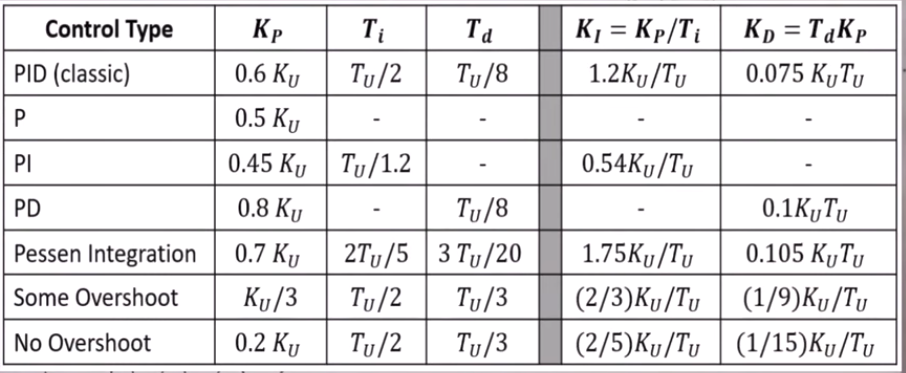
Tunning Table from Christopher Lum - https://www.youtube.com/watch?v=n829SwSUZ_c
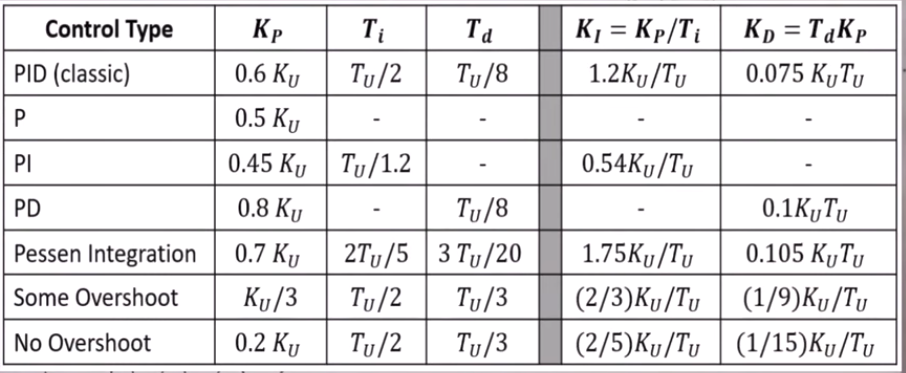

In [192]:
if is_oscillation_stable and tu is not None:
    ku = kp  # Ultimate gain
    print(f"Ultimate Gain (Ku): {ku}")
    print(f"Ultimate Period (Tu): {tu:.4f} s")

    # Ziegler-Nichols PID Tuning Rules for No Overshoot
    kp = 0.2 * ku 
    ki = (2/5) * (ku / tu)
    kd = (1/15) * (ku * tu)

    print(f"Computed PID Parameters:")
    print(f"Kp: {kp:.4f}")
    print(f"Ki: {ki:.4f}")
    print(f"Kd: {kd:.4f}")
else:
    print("Oscillation is not stable or Tu is None. Cannot compute PID parameters.")

Ultimate Gain (Ku): 0.15
Ultimate Period (Tu): 1.8137 s
Computed PID Parameters:
Kp: 0.0300
Ki: 0.0331
Kd: 0.0181


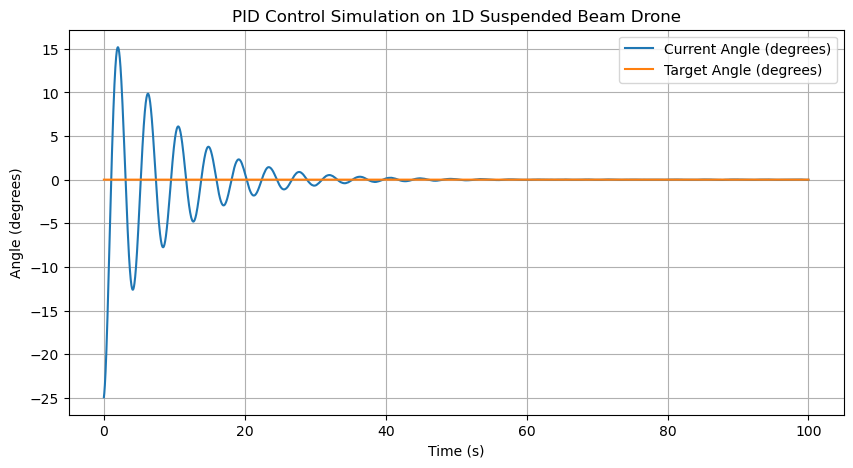

In [193]:
time_history, target_angle_history, current_angle_history = run_simulation(kp, ki, kd)
plot_results(time_history, target_angle_history, current_angle_history)